# 02 — Grid World from Scratch
**Week 3 | RL Fundamentals**

We build a 5×5 Grid World **without any RL library**. This forces you to understand every part of the environment interface that Gymnasium later hides from you.

```
[ S ][ . ][ . ][ . ][ . ]
[ . ][ # ][ . ][ # ][ . ]
[ . ][ . ][ . ][ . ][ . ]
[ . ][ # ][ . ][ # ][ . ]
[ . ][ . ][ . ][ . ][ G ]
```
S = start, G = goal (+10), # = pit (-5 and terminal), . = empty (-0.1 step cost

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
np.random.seed(0)

In [2]:
class GridWorld:
    """
    5x5 Grid World environment.
    Actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
    """
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    ACTION_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal  = (size-1, size-1)
        self.pits  = {(1,1), (1,3), (3,1), (3,3)}
        self.reset()

    def reset(self):
        self.pos = self.start
        return self._state()

    def _state(self):
        return self.pos[0] * self.size + self.pos[1]   # flat index

    def n_states(self):  return self.size ** 2
    def n_actions(self): return 4

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)

        if self.pos == self.goal:
            return self._state(), +10.0, True
        if self.pos in self.pits:
            return self._state(),  -5.0, True
        return self._state(), -0.1, False

    def render_values(self, V, title='Value Function'):
        grid = np.array(V).reshape(self.size, self.size)
        fig, ax = plt.subplots(figsize=(5, 5))
        im = ax.imshow(grid, cmap='RdYlGn', vmin=grid.min(), vmax=grid.max())
        plt.colorbar(im, ax=ax)
        for r in range(self.size):
            for c in range(self.size):
                marker = ''
                if (r,c) == self.goal:          marker = 'G'
                elif (r,c) == self.start:       marker = 'S'
                elif (r,c) in self.pits:        marker = '✕'
                ax.text(c, r, f'{marker}\n{grid[r,c]:.1f}', ha='center', va='center', fontsize=9)
        ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
        plt.tight_layout(); plt.show()

    def render_policy(self, policy, title='Policy'):
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.set_xlim(-0.5, self.size-0.5); ax.set_ylim(-0.5, self.size-0.5)
        ax.set_xticks(range(self.size)); ax.set_yticks(range(self.size))
        ax.grid(True, linewidth=0.5)
        for r in range(self.size):
            for c in range(self.size):
                s = r * self.size + c
                if (r,c) == self.goal:    ax.text(c, self.size-1-r, 'G', ha='center', va='center', fontsize=16, color='green')
                elif (r,c) in self.pits: ax.text(c, self.size-1-r, '✕', ha='center', va='center', fontsize=16, color='red')
                else:                    ax.text(c, self.size-1-r, self.ACTION_SYMBOLS[policy[s]], ha='center', va='center', fontsize=18)
        ax.set_title(title); plt.tight_layout(); plt.show()

env = GridWorld()
print(f"States: {env.n_states()}, Actions: {env.n_actions()}")
print(f"Start: {env.start}, Goal: {env.goal}, Pits: {env.pits}")

States: 25, Actions: 4
Start: (0, 0), Goal: (4, 4), Pits: {(3, 1), (1, 1), (3, 3), (1, 3)}


## 2. Random Policy Rollout

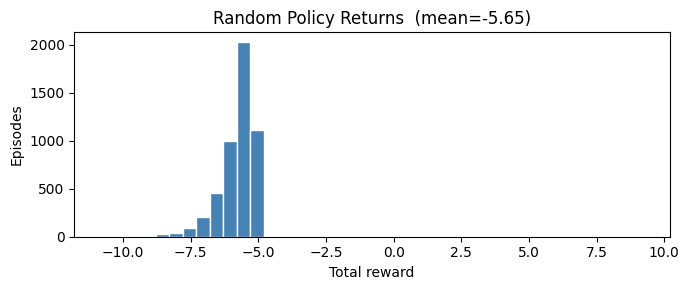

In [3]:
def rollout(env, policy_fn, max_steps=100):
    state = env.reset()
    total_reward = 0.0
    steps = 0
    done = False
    while not done and steps < max_steps:
        action = policy_fn(state)
        state, reward, done = env.step(action)
        total_reward += reward
        steps += 1
    return total_reward, done, steps

returns = []
for _ in range(5000):
    r, done, _ = rollout(env, lambda s: np.random.randint(4))
    returns.append(r)

plt.figure(figsize=(7, 3))
plt.hist(returns, bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Total reward'); plt.ylabel('Episodes')
plt.title(f'Random Policy Returns  (mean={np.mean(returns):.2f})')
plt.tight_layout(); plt.show()

## 3. Visualise a Uniform Random Value Function
(Not yet optimal — we'll fix that in Week 4)

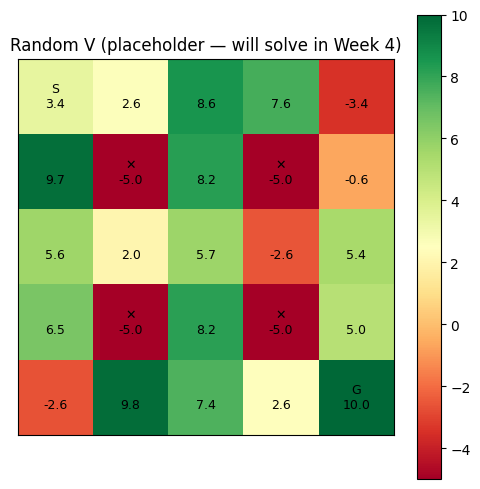

In [4]:
# Placeholder: uniform random values just to show the visualisation
V_random = np.random.uniform(-5, 10, env.n_states())
# Mark terminal states
V_random[env.goal[0]*env.size + env.goal[1]] = 10
for p in env.pits:
    V_random[p[0]*env.size + p[1]] = -5
env.render_values(V_random, title='Random V (placeholder — will solve in Week 4)')

## ✅ Exercises
1. Add a **stochastic** step function: with probability 0.1, the agent moves in a random direction instead of its intended direction (slippery floor). How does this change the rollout returns?
2. Change the pit penalty from -5 to -1. How does the distribution of returns change?
3. **Challenge**: add a 'treasure' cell at (2,2) that gives +3 reward but does NOT end the episode. Does a random policy find it often?

## Question 1.

In [5]:
def step_slippery(self, action, slip_prob=0.1):
    if np.random.rand() < slip_prob:
        action = np.random.randint(4)  
    dr, dc = self.ACTIONS[action]
    r, c = self.pos
    nr = max(0, min(self.size-1, r + dr))
    nc = max(0, min(self.size-1, c + dc))
    self.pos = (nr, nc)

    if self.pos == self.goal:
        return self._state(), +10.0, True
    if self.pos in self.pits:
        return self._state(), -5.0, True
    return self._state(), -0.1, False
    
GridWorld.step_slippery = step_slippery

In [6]:
def rollout_slippery(env, policy_fn, max_steps=100):
    state = env.reset()
    total_reward = 0.0
    steps = 0
    done = False
    while not done and steps < max_steps:
        action = policy_fn(state)
        state, reward, done = env.step_slippery(action)
        total_reward += reward
        steps += 1
    return total_reward, done, steps

returns_slippery = []
for _ in range(5000):
    r, done, _ = rollout_slippery(env, lambda s: np.random.randint(4))
    returns_slippery.append(r)

print("Normal mean:", np.mean(returns))
print("Slippery mean:", np.mean(returns_slippery))

Normal mean: -5.64924
Slippery mean: -5.654120000000001


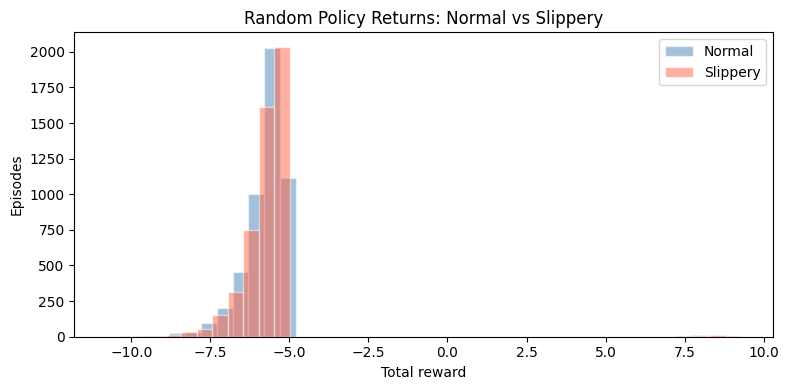

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(returns, bins=40, alpha=0.5, color='steelblue', edgecolor='white', label='Normal')
plt.hist(returns_slippery, bins=40, alpha=0.5, color='tomato', edgecolor='white', label='Slippery')
plt.xlabel('Total reward'); plt.ylabel('Episodes')
plt.title('Random Policy Returns: Normal vs Slippery')
plt.legend()
plt.tight_layout(); plt.show()

When we add the slippery floor (10% chance the agent moves in a random direction instead of what it intended), the random policy's returns get slightly worse on average.

Normal mean reward: -5.64924
  
Slippery mean reward: -5.654120000000001

because the random direction flip can sometimes push the agent into a pit it wouldn't have hit otherwise, which costs -5 and ends the episode early. It can also occasionally help, but since there are 4 pits and only 1 goal, the odds of slipping into something bad are higher than slipping into something good. So overall the distribution shifts slightly left (lower rewards) and gets a bit noisier/wider compared to the normal version.

## Question 2.


In [8]:
class GridWorldLowPit(GridWorld):
    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)

        if self.pos == self.goal:
            return self._state(), +10.0, True
        if self.pos in self.pits:
            return self._state(), -1.0, True   # changed from -5.0
        return self._state(), -0.1, False

env_lowpit = GridWorldLowPit()

In [9]:
returns_lowpit = []
for _ in range(5000):
    r, done, _ = rollout(env_lowpit, lambda s: np.random.randint(4))
    returns_lowpit.append(r)

print("Original (-5 pit) mean:", np.mean(returns))
print("Low pit (-1) mean:", np.mean(returns_lowpit))

Original (-5 pit) mean: -5.64924
Low pit (-1) mean: -1.6763400000000002


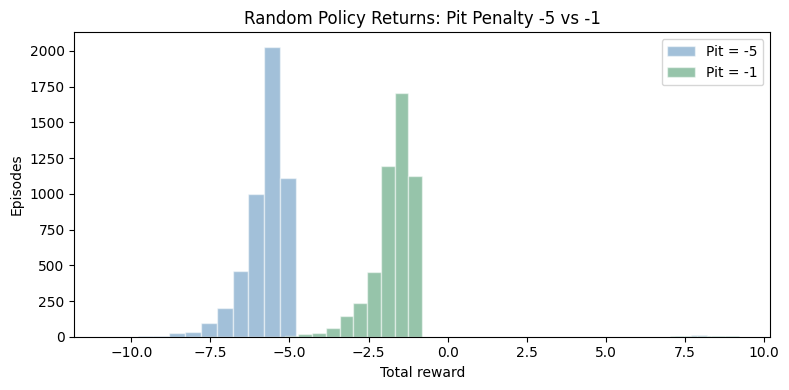

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(returns, bins=40, alpha=0.5, color='steelblue', edgecolor='white', label='Pit = -5')
plt.hist(returns_lowpit, bins=40, alpha=0.5, color='seagreen', edgecolor='white', label='Pit = -1')
plt.xlabel('Total reward'); plt.ylabel('Episodes')
plt.title('Random Policy Returns: Pit Penalty -5 vs -1')
plt.legend()
plt.tight_layout(); plt.show()

The whole distribution shifted towards right and the random policy returns shifts higher compared to original and it can be verified as 

Original (pit = -5) mean reward: -5.64924

Low pit (pit = -1) mean reward:  -1.6763400000000002

as hitting a pitch is much less costly now .


## Question 3.

In [11]:
class GridWorldTreasure(GridWorld):
    def __init__(self, size=5):
        super().__init__(size)
        self.treasure = (2, 2)
        self.treasure_collected = False

    def reset(self):
        self.treasure_collected = False
        return super().reset()

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)

        if self.pos == self.goal:
            return self._state(), +10.0, True
        if self.pos in self.pits:
            return self._state(), -5.0, True
        if self.pos == self.treasure and not self.treasure_collected:
            self.treasure_collected = True
            return self._state(), +3.0 - 0.1, False
        return self._state(), -0.1, False

env_treasure = GridWorldTreasure()
print("Treasure location:", env_treasure.treasure)

Treasure location: (2, 2)


In [12]:
def rollout_track_treasure(env, policy_fn, max_steps=100):
    state = env.reset()
    total_reward = 0.0
    steps = 0
    done = False
    while not done and steps < max_steps:
        action = policy_fn(state)
        state, reward, done = env.step(action)
        total_reward += reward
        steps += 1
    return total_reward, env.treasure_collected

returns_treasure = []
found_treasure = []
for _ in range(5000):
    r, found = rollout_track_treasure(env_treasure, lambda s: np.random.randint(4))
    returns_treasure.append(r)
    found_treasure.append(found)

frac_found = np.mean(found_treasure)
print(f"Fraction of episodes that found the treasure: {frac_found:.4f}")
print(f"Mean reward with treasure: {np.mean(returns_treasure):.2f}")
print(f"Original mean (no treasure): {np.mean(returns):.2f}")

Fraction of episodes that found the treasure: 0.0714
Mean reward with treasure: -5.44
Original mean (no treasure): -5.65


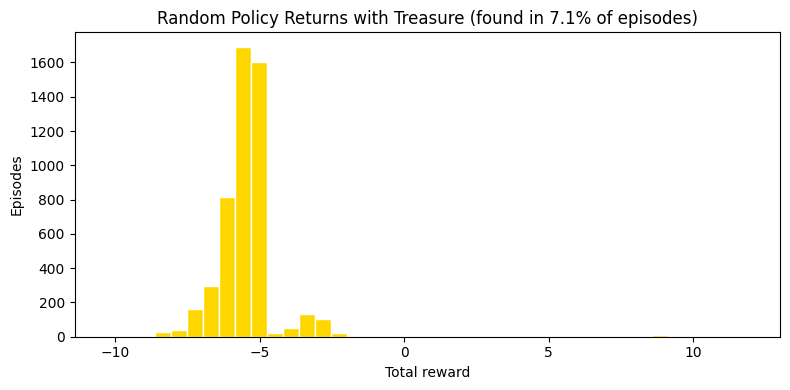

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(returns_treasure, bins=40, color='gold', edgecolor='white')
plt.xlabel('Total reward'); plt.ylabel('Episodes')
plt.title(f'Random Policy Returns with Treasure (found in {frac_found*100:.1f}% of episodes)')
plt.tight_layout(); plt.show()

No, a random policy doesn't finds the treasure fairly often.
In my run, the fraction of episodes that found it was 0.0714 .